In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cdist
from math import sqrt, pow

In [38]:

class POINT:
    def __init__(self, cl, x_vec):
        self.clust = cl
        self.coords = np.array(x_vec)

class CLUSTER:
    def __init__(self, cl, x_vec):
        self.clust = cl
        self.coords = np.array(x_vec)
        self.N = 0

    def Dist(self, p):
        return sqrt(np.sum((self.coords - p.coords) ** 2))

    def Eval_Center(self, P, M):
        self.N = 0
        self.coords = np.zeros_like(self.coords)
        a = 0.0
        for i in range(len(P)):
            if P[i].clust == self.clust:
                self.N += 1
                self.coords += P[i].coords * M[i][self.clust]
                a += M[i][self.clust]
        if a != 0.0:
            self.coords /= a

def fuzzy_c_means_custom(X, n_clusters, m=2.0, max_iter=100, tol=0.1):
    n_samples, n_features = X.shape
    PP = [POINT(n_clusters, X[i]) for i in range(n_samples)]

    idx = np.random.choice(n_samples, n_clusters, replace=False)
    Cl = [CLUSTER(k, X[idx[k]]) for k in range(n_clusters)]

    for it in range(max_iter):
        CC = [CLUSTER(k, Cl[k].coords) for k in range(n_clusters)]

        Mu = []
        for i in range(n_samples):
            Mu.append([])
            zero_idx = None
            for k in range(n_clusters):
                d = Cl[k].Dist(PP[i])
                if d == 0.0:
                    zero_idx = k
                    break
            if zero_idx is not None:
                Mu[i] = [0.0] * n_clusters
                Mu[i][zero_idx] = 1.0
                continue

            a = 0.0
            for k in range(n_clusters):
                val = 1.0 / pow(Cl[k].Dist(PP[i]), 2.0 / (m - 1.0))
                Mu[i].append(val)
                a += val
            for k in range(n_clusters):
                Mu[i][k] /= a

        for i in range(n_samples):
            r = np.random.rand()
            prob = 0.0
            for k in range(n_clusters):
                prob += Mu[i][k]
                if r < prob:
                    PP[i].clust = k
                    break

        for k in range(n_clusters):
            Cl[k].Eval_Center(PP, Mu)

        max_shift = max(Cl[k].Dist(CC[k]) for k in range(n_clusters))
        if max_shift < tol:
            break

    labels = np.array([p.clust for p in PP])
    centers = np.array([cl.coords for cl in Cl])
    Mu_matrix = np.array(Mu)
    return labels, centers, Mu_matrix


In [39]:

class CLUSTER_RADIUS(CLUSTER):
    def __init__(self, cl, x_vec):
        super().__init__(cl, x_vec)

    def delta(self, P):
        n = 0
        summ = 0.0
        for p in P:
            if p.clust == self.clust:
                n += 1
                summ += np.sum((self.coords - p.coords) ** 2)
        return summ / n if n > 0 else 0.0

    def radius(self, P, n_clusters):
        return sqrt(n_clusters * self.delta(P))

def kmeans_radius_custom(X, n_clusters, max_iter=100, tol=0.001):
    n_samples, n_features = X.shape
    PP = [POINT(n_clusters, X[i]) for i in range(n_samples)]

    idx = np.random.choice(n_samples, n_clusters, replace=False)
    Cl = [CLUSTER_RADIUS(k, X[idx[k]]) for k in range(n_clusters)]

    for it in range(max_iter):
        CC = [CLUSTER_RADIUS(k, Cl[k].coords) for k in range(n_clusters)]

        radii = [Cl[k].radius(PP, n_clusters) for k in range(n_clusters)]

        for p in PP:
            distances = [Cl[k].Dist(p) for k in range(n_clusters)]
            min_dist = min(distances)
            min_idx = np.argmin(distances)
            if min_dist <= radii[min_idx]:
                p.clust = min_idx
            else:
                p.clust = -1

        for k in range(n_clusters):
            Cl[k].Eval_Center(PP, np.ones((n_samples, n_clusters)))

        max_shift = max(Cl[k].Dist(CC[k]) for k in range(n_clusters))
        if max_shift < tol:
            break

    labels = np.array([p.clust for p in PP])
    centers = np.array([cl.coords for cl in Cl])
    return labels, centers


In [40]:

def roc_curve_manual(y_true, y_score):
    # Сортируем по убыванию score
    desc_idx = np.argsort(y_score)[::-1]
    y_score_sorted = y_score[desc_idx]
    y_true_sorted = y_true[desc_idx]

    tpr = [0.0]
    fpr = [0.0]
    thresholds = [y_score_sorted[0] + 1e-6]

    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)

    if pos == 0 or neg == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.array([0.0, 0.0])

    tp = 0
    fp = 0
    prev_score = y_score_sorted[0]

    for i, score in enumerate(y_score_sorted):
        if score != prev_score:
            tpr.append(tp / pos)
            fpr.append(fp / neg)
            thresholds.append(prev_score)
            prev_score = score
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1

    tpr.append(tp / pos)
    fpr.append(fp / neg)
    thresholds.append(prev_score)

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    thresholds = np.array(thresholds)

    return fpr, tpr, thresholds

def compute_auc_manual(fpr, tpr):
    auc = 0.0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        height = (tpr[i] + tpr[i-1]) / 2.0
        auc += width * height
    return auc

def plot_roc_curves(roc_data, auc_scores, title='ROC-кривые (ручной расчёт)'):
    plt.figure(figsize=(10, 8))
    colors = {'FCM': 'green', 'K-Means (радиус)': 'blue', 'KNN': 'red'}
    for name, curves in roc_data.items():
        if not curves:
            continue
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []
        for fpr, tpr in curves:
            tprs.append(np.interp(mean_fpr, fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = auc_scores[name]
        plt.plot(mean_fpr, mean_tpr, color=colors[name],
                 label=f'{name} (AUC = {mean_auc:.3f})', lw=2)

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайное угадывание')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


In [41]:

def evaluate_dataset(X, y_true, n_clusters, dataset_name=''):
    y_true_bin = label_binarize(y_true, classes=range(n_clusters))

    results = {}
    auc_scores = {}
    roc_data = {}

    # FCM
    labels_fcm, _, Mu_fcm = fuzzy_c_means_custom(X, n_clusters)
    results['FCM'] = labels_fcm
    roc_fcm = []
    auc_fcm = []
    for i in range(n_clusters):
        if len(np.unique(y_true_bin[:, i])) == 2:
            fpr, tpr, _ = roc_curve_manual(y_true_bin[:, i], Mu_fcm[:, i])
            roc_fcm.append((fpr, tpr))
            auc_fcm.append(compute_auc_manual(fpr, tpr))
    auc_scores['FCM'] = np.mean(auc_fcm) if auc_fcm else 0.5
    roc_data['FCM'] = roc_fcm

    # K-Means с радиусом
    labels_kmeans_rad, centers = kmeans_radius_custom(X, n_clusters)
    mask = labels_kmeans_rad != -1
    n_train = np.sum(mask)
    if n_train > 0:
        dist = cdist(X[mask], centers)
        prob = np.exp(-dist) / np.sum(np.exp(-dist), axis=1, keepdims=True)
        full_prob = np.ones((X.shape[0], n_clusters)) / n_clusters
        full_prob[mask] = prob
    else:
        full_prob = np.ones((X.shape[0], n_clusters)) / n_clusters
    results['K-Means (радиус)'] = labels_kmeans_rad
    roc_kmeans = []
    auc_kmeans = []
    for i in range(n_clusters):
        if len(np.unique(y_true_bin[:, i])) == 2:
            fpr, tpr, _ = roc_curve_manual(y_true_bin[:, i], full_prob[:, i])
            roc_kmeans.append((fpr, tpr))
            auc_kmeans.append(compute_auc_manual(fpr, tpr))
    auc_scores['K-Means (радиус)'] = np.mean(auc_kmeans) if auc_kmeans else 0.5
    roc_data['K-Means (радиус)'] = roc_kmeans

    # KNN (обучен на метках K-Means)
    desired_n_neighbors = 5
    if n_train == 0:
        prob_knn = np.ones((X.shape[0], n_clusters)) / n_clusters
        labels_knn = np.zeros(X.shape[0])
    else:
        actual_n_neighbors = min(desired_n_neighbors, n_train)
        knn = KNeighborsClassifier(n_neighbors=actual_n_neighbors)
        knn.fit(X[mask], labels_kmeans_rad[mask])
        prob_knn = knn.predict_proba(X)
        labels_knn = knn.predict(X)

    results['KNN'] = labels_knn
    roc_knn = []
    auc_knn = []
    for i in range(n_clusters):
        if len(np.unique(y_true_bin[:, i])) == 2:
            fpr, tpr, _ = roc_curve_manual(y_true_bin[:, i], prob_knn[:, i])
            roc_knn.append((fpr, tpr))
            auc_knn.append(compute_auc_manual(fpr, tpr))
    auc_scores['KNN'] = np.mean(auc_knn) if auc_knn else 0.5
    roc_data['KNN'] = roc_knn

    plot_roc_curves(roc_data, auc_scores, title=f'ROC-кривые – {dataset_name}')

    return auc_scores


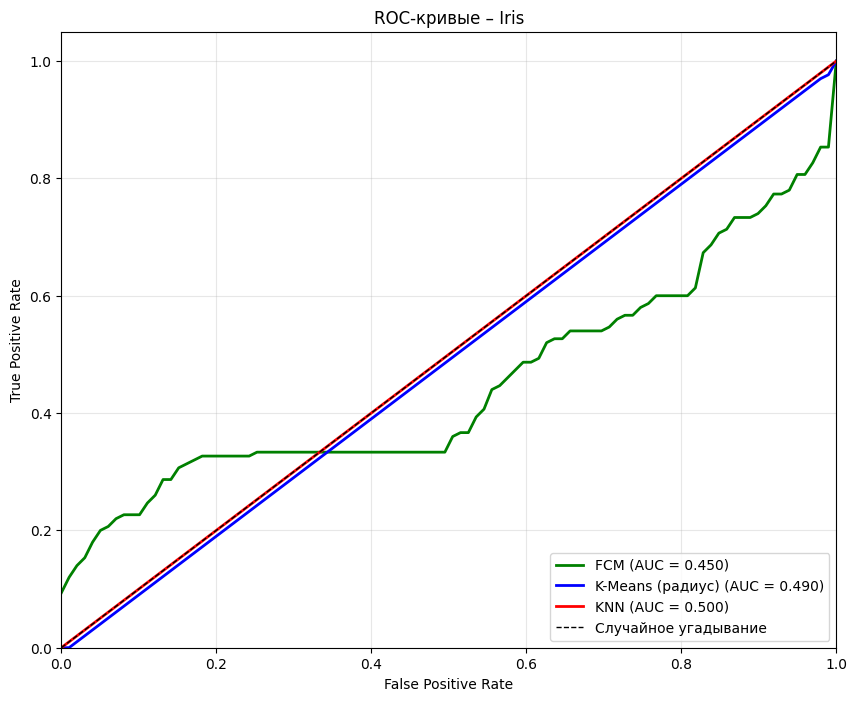

AUC scores (Iris):
  FCM: 0.4495
  K-Means (радиус): 0.4901
  KNN: 0.5000


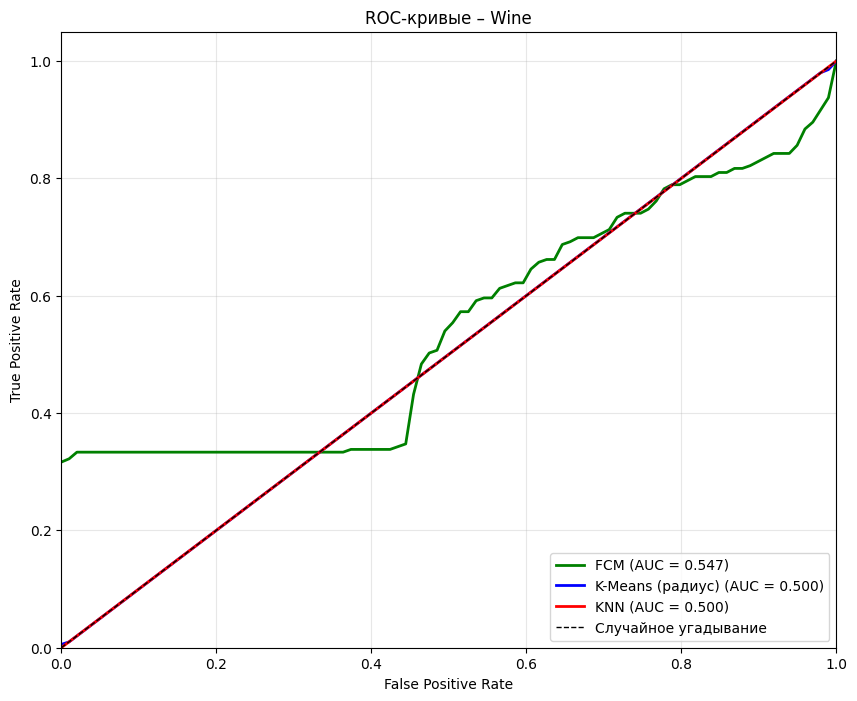

AUC scores (Wine):
  FCM: 0.5466
  K-Means (радиус): 0.5000
  KNN: 0.5000


In [42]:

iris = datasets.load_iris()
wine = datasets.load_wine()

X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
n_clusters_iris = 3

X_wine = StandardScaler().fit_transform(wine.data)
y_wine = wine.target
n_clusters_wine = 3

# Оценка Iris
auc_iris = evaluate_dataset(X_iris, y_iris, n_clusters_iris, 'Iris')
print("AUC scores (Iris):")
for algo, auc in auc_iris.items():
    print(f"  {algo}: {auc:.4f}")

# Оценка Wine
auc_wine = evaluate_dataset(X_wine, y_wine, n_clusters_wine, 'Wine')
print("AUC scores (Wine):")
for algo, auc in auc_wine.items():
    print(f"  {algo}: {auc:.4f}")


In [43]:
df_results = pd.DataFrame([auc_iris, auc_wine], index=['Iris', 'Wine'])
df_results

,FCM,K-Means (радиус),KNN
Iris,0.449533,0.490067,0.5
Wine,0.546595,0.500015,0.5


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from math import sqrt


In [45]:

class POINT:
    def __init__(self, cl, x_vec):
        self.clust = cl
        self.coords = np.array(x_vec)


class CLUSTER:
    def __init__(self, cl, x_vec):
        self.clust = cl
        self.coords = np.array(x_vec)

    def Dist(self, p):
        return sqrt(np.sum((self.coords - p.coords) ** 2))

    def Eval_Center(self, P, M, m):
        self.coords = np.zeros_like(self.coords)
        a = 0.0
        for i in range(len(P)):
            w = (M[i][self.clust] ** m)
            self.coords += P[i].coords * w
            a += w
        if a != 0.0:
            self.coords /= a


def fuzzy_c_means_custom(X, n_clusters, m=2.0, max_iter=100, tol=1e-4):
    n_samples = X.shape[0]
    PP = [POINT(0, X[i]) for i in range(n_samples)]

    idx = np.random.choice(n_samples, n_clusters, replace=False)
    Cl = [CLUSTER(k, X[idx[k]]) for k in range(n_clusters)]

    Mu = np.zeros((n_samples, n_clusters))

    for _ in range(max_iter):
        old_centers = np.array([cl.coords.copy() for cl in Cl])

        # --- membership ---
        for i in range(n_samples):
            dists = np.array([Cl[k].Dist(PP[i]) for k in range(n_clusters)])

            if np.any(dists == 0):
                Mu[i] = 0
                Mu[i][np.argmin(dists)] = 1
            else:
                inv = 1.0 / (dists ** (2 / (m - 1)))
                Mu[i] = inv / np.sum(inv)

        # --- centers ---
        for k in range(n_clusters):
            Cl[k].Eval_Center(PP, Mu, m)

        new_centers = np.array([cl.coords for cl in Cl])
        shift = np.max(np.linalg.norm(new_centers - old_centers, axis=1))

        if shift < tol:
            break

    labels = np.argmax(Mu, axis=1)
    centers = np.array([cl.coords for cl in Cl])

    return labels, centers, Mu


In [46]:

def match_clusters(y_true, labels, n_clusters):
    cm = confusion_matrix(y_true, labels, labels=range(n_clusters))
    row_ind, col_ind = linear_sum_assignment(-cm)
    return {col: row for row, col in zip(row_ind, col_ind)}


def reorder_probabilities(prob, mapping, n_clusters):
    new_prob = np.zeros_like(prob)
    for old_k, new_k in mapping.items():
        new_prob[:, new_k] = prob[:, old_k]
    return new_prob


def roc_curve_manual(y_true, y_score):
    desc_idx = np.argsort(y_score)[::-1]
    y_score_sorted = y_score[desc_idx]
    y_true_sorted = y_true[desc_idx]

    tpr = [0.0]
    fpr = [0.0]

    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)

    if pos == 0 or neg == 0:
        return np.array([0, 1]), np.array([0, 1])

    tp = 0
    fp = 0

    for i in range(len(y_score_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1

        tpr.append(tp / pos)
        fpr.append(fp / neg)

    return np.array(fpr), np.array(tpr)


In [47]:

def compute_auc_manual(fpr, tpr):
    auc = 0.0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i - 1]
        height = (tpr[i] + tpr[i - 1]) / 2.0
        auc += width * height
    return auc


def plot_roc_curves(roc_data, auc_scores, title='ROC'):
    plt.figure(figsize=(8, 6))

    for name, curves in roc_data.items():
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []

        for fpr, tpr in curves:
            tprs.append(np.interp(mean_fpr, fpr, tpr))

        mean_tpr = np.mean(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr,
                 label=f'{name} (AUC={auc_scores[name]:.3f})')

    plt.plot([0, 1], [0, 1], '--')
    plt.legend()
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid()
    plt.show()


In [48]:

def evaluate_dataset(X, y_true, n_clusters, dataset_name=''):
    y_bin = label_binarize(y_true, classes=range(n_clusters))

    roc_data = {}
    auc_scores = {}

    # ===== FCM =====
    labels_fcm, _, Mu = fuzzy_c_means_custom(X, n_clusters)
    mapping = match_clusters(y_true, labels_fcm, n_clusters)
    Mu = reorder_probabilities(Mu, mapping, n_clusters)

    roc_fcm, auc_fcm = [], []
    for i in range(n_clusters):
        fpr, tpr = roc_curve_manual(y_bin[:, i], Mu[:, i])
        roc_fcm.append((fpr, tpr))
        auc_fcm.append(compute_auc_manual(fpr, tpr))

    roc_data['FCM'] = roc_fcm
    auc_scores['FCM'] = np.mean(auc_fcm)

    # ===== KMeans =====
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=n_clusters, n_init=10)
    labels_km = km.fit_predict(X)

    dist = cdist(X, km.cluster_centers_)
    prob_km = np.exp(-dist) / np.sum(np.exp(-dist), axis=1, keepdims=True)

    mapping = match_clusters(y_true, labels_km, n_clusters)
    prob_km = reorder_probabilities(prob_km, mapping, n_clusters)

    roc_km, auc_km = [], []
    for i in range(n_clusters):
        fpr, tpr = roc_curve_manual(y_bin[:, i], prob_km[:, i])
        roc_km.append((fpr, tpr))
        auc_km.append(compute_auc_manual(fpr, tpr))

    roc_data['KMeans'] = roc_km
    auc_scores['KMeans'] = np.mean(auc_km)

    # ===== KNN =====
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X, labels_km)
    prob_knn = knn.predict_proba(X)
    prob_knn = reorder_probabilities(prob_knn, mapping, n_clusters)

    roc_knn, auc_knn = [], []
    for i in range(n_clusters):
        fpr, tpr = roc_curve_manual(y_bin[:, i], prob_knn[:, i])
        roc_knn.append((fpr, tpr))
        auc_knn.append(compute_auc_manual(fpr, tpr))

    roc_data['KNN'] = roc_knn
    auc_scores['KNN'] = np.mean(auc_knn)

    plot_roc_curves(roc_data, auc_scores, f'ROC – {dataset_name}')

    return auc_scores


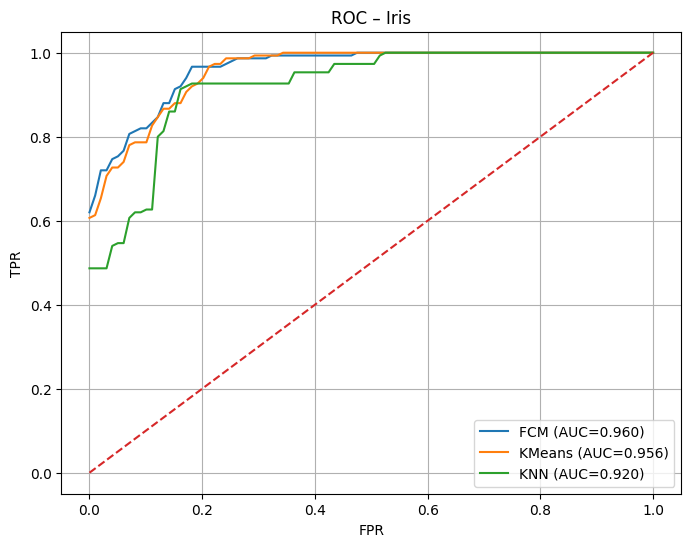

Iris: {'FCM': np.float64(0.9603333333333334), 'KMeans': np.float64(0.9558666666666668), 'KNN': np.float64(0.9198)}


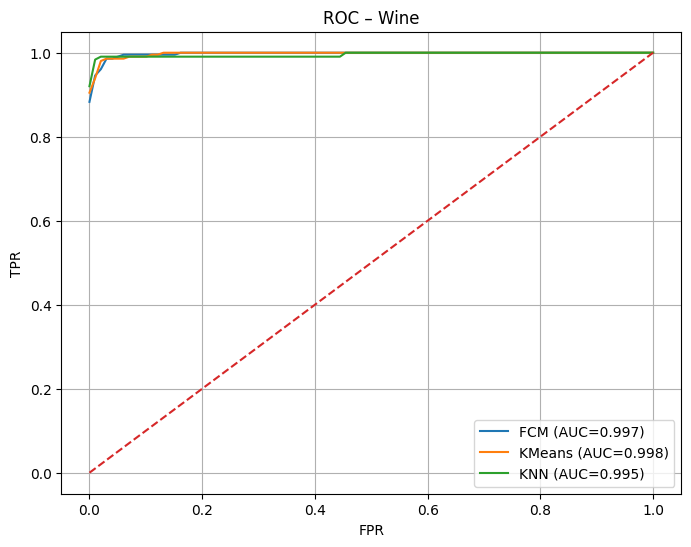

Wine: {'FCM': np.float64(0.9973900486991653), 'KMeans': np.float64(0.9975312823080006), 'KNN': np.float64(0.9951527883901039)}
           FCM    KMeans       KNN
Iris  0.960333  0.955867  0.919800
Wine  0.997390  0.997531  0.995153


In [49]:

iris = datasets.load_iris()
wine = datasets.load_wine()

X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

X_wine = StandardScaler().fit_transform(wine.data)
y_wine = wine.target

auc_iris = evaluate_dataset(X_iris, y_iris, 3, 'Iris')
print("Iris:", auc_iris)

auc_wine = evaluate_dataset(X_wine, y_wine, 3, 'Wine')
print("Wine:", auc_wine)

df = pd.DataFrame([auc_iris, auc_wine], index=['Iris', 'Wine'])
print(df)